Improving Customer Satisfaction through Automated Review Sentiment Analysis
Overview
You are a product manager at an e-commerce company like Amazon. Your company receives thousands of customer reviews daily for various products. While ratings are available, they don’t always capture customer sentiment accurately — especially when the text and rating conflict.
Business Problem:
Your goal is to build an automated Sentiment Analysis System to classify incoming product reviews as Positive or Negative. This will help:
Monitor product performance in real-time
Identify products with sudden spikes in negative feedback
Improve customer satisfaction by addressing complaints faster

Dataset
Each row is one Amazon customer review for some product.
The dataset has been pre-labeled — so you already know if the review is positive or negative.
This is a typical sentiment analysis dataset, often used for training or testing natural language processing (NLP) models.
📊 Rows:
10,000 customer reviews
📑 Columns:
1.label
oType: Text (Categorical)
oValues: pos (positive) or neg (negative)
oWhat it means: The sentiment of the review — whether the customer’s feedback is positive or negative.
2.review
oType: Text
oValues: Actual text of the review written by the customer.
oWhat it means: What the customer said about the product in their own words — for example: “Excellent Soundtrack! I love it!”

Tasks
Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).
Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.
Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.
Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score.


Submission Guidelines
Your submission should include a comprehensive report and the complete codebase.
Your code should be well-documented and include comments explaining the major steps.
Evaluation Criteria
Correct implementation of data preprocessing and feature extraction.
Accuracy and robustness of the classification model.
Depth and insightfulness of the sentiment analysis.
Clarity and thoroughness of the evaluation and discussion sections.
Overall quality and organization of the report and code.
Good luck, and we look forward to your insightful analysis of the given dataset!


1.Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Akshay\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")

df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 2)


In [8]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
print(df["label"].value_counts())

label
neg    5097
pos    4903
Name: count, dtype: int64


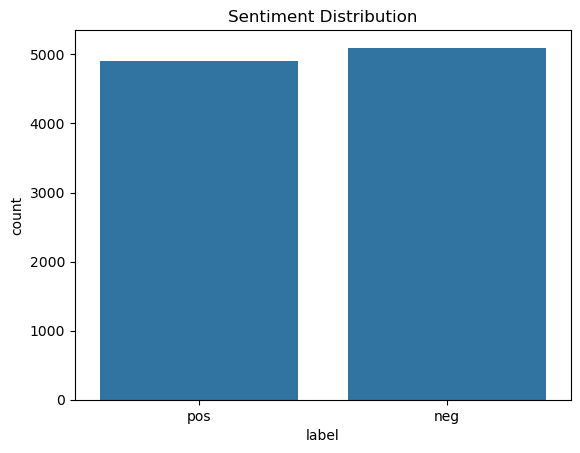

In [12]:
sns.countplot(x="label", data=df)
plt.title("Sentiment Distribution")
plt.show()

In [13]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

df.head()

,label,review,clean_review
0,pos,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,pos,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,pos,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,pos,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,pos,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


2.Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.

In [14]:
!pip install wordcloud

In [15]:
from wordcloud import WordCloud

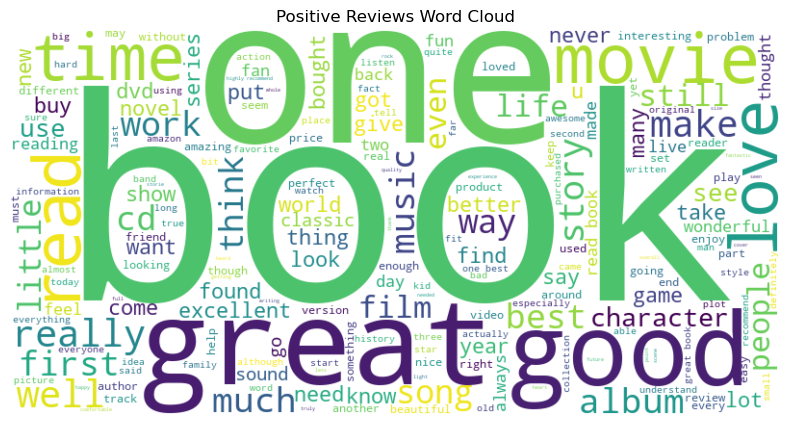

In [16]:
positive_text = " ".join(df[df["label"]=="pos"]["clean_review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

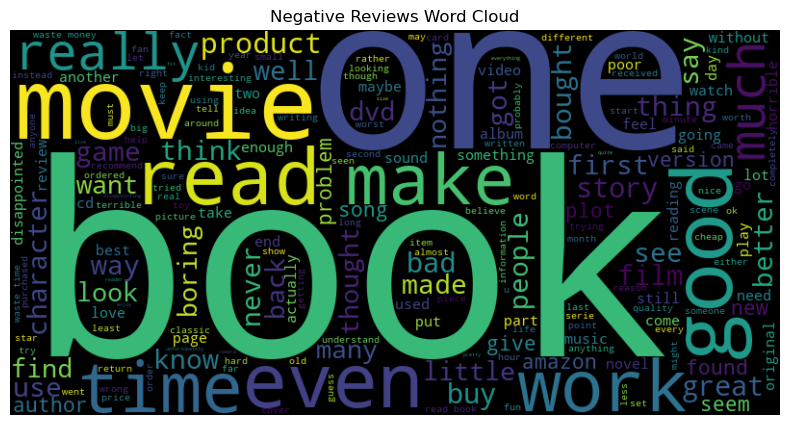

In [17]:
negative_text = " ".join(df[df["label"]=="neg"]["clean_review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="black"
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [18]:
from collections import Counter

positive_words = " ".join(df[df["label"]=="pos"]["clean_review"]).split()

common_positive = Counter(positive_words).most_common(20)

common_positive

[('book', 3390),
 ('great', 2135),
 ('one', 1916),
 ('good', 1667),
 ('read', 1605),
 ('like', 1290),
 ('movie', 1121),
 ('would', 956),
 ('well', 944),
 ('time', 924),
 ('love', 911),
 ('really', 832),
 ('best', 813),
 ('get', 805),
 ('story', 730),
 ('first', 724),
 ('much', 664),
 ('cd', 618),
 ('music', 577),
 ('also', 575)]

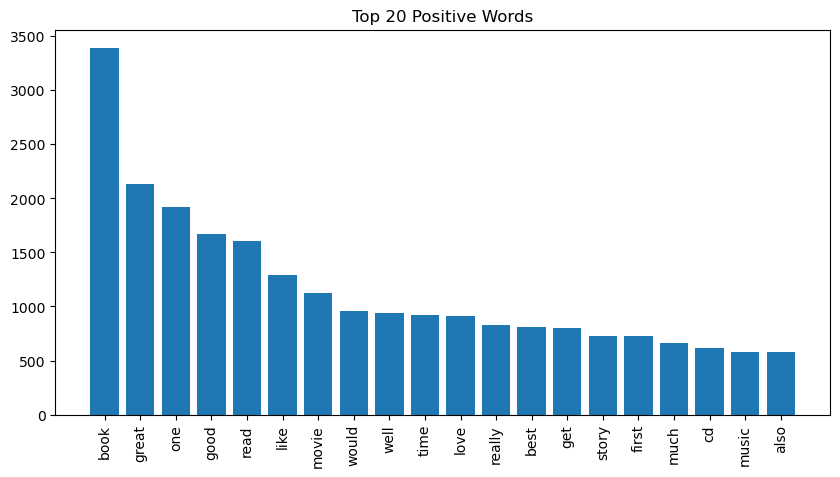

In [19]:
words = [x[0] for x in common_positive]
counts = [x[1] for x in common_positive]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Positive Words")
plt.show()

In [20]:
negative_words = " ".join(df[df["label"]=="neg"]["clean_review"]).split()

common_negative = Counter(negative_words).most_common(20)

common_negative

[('book', 3277),
 ('one', 2100),
 ('like', 1569),
 ('movie', 1519),
 ('would', 1465),
 ('read', 1222),
 ('good', 1160),
 ('get', 1151),
 ('time', 1072),
 ('even', 910),
 ('buy', 835),
 ('really', 783),
 ('much', 782),
 ('money', 767),
 ('bad', 764),
 ('first', 760),
 ('better', 677),
 ('could', 667),
 ('great', 644),
 ('story', 641)]

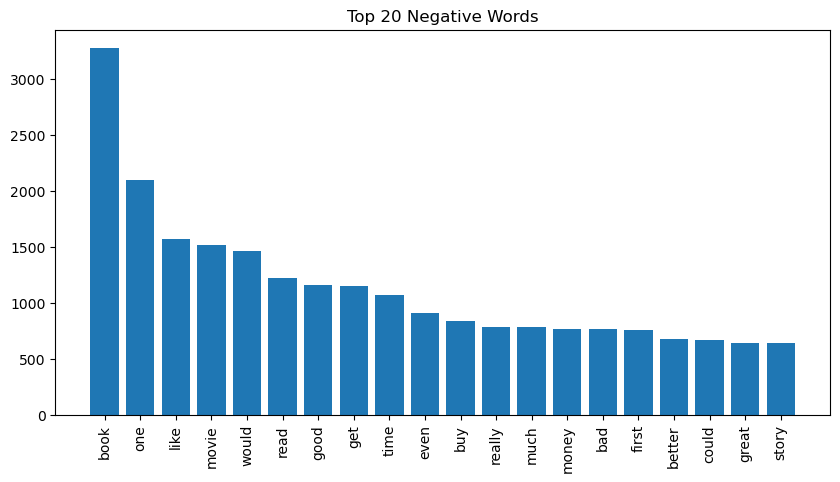

In [21]:
words = [x[0] for x in common_negative]
counts = [x[1] for x in common_negative]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Negative Words")
plt.show()

3.Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [23]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

y = df["label"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 5000)
(2000, 5000)


In [25]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.851


## Model Development

TF-IDF Vectorizer was used to convert the cleaned text into numerical feature vectors.

A Logistic Regression classifier was trained on the training dataset and used to predict the sentiment of unseen reviews.

The model learns to classify reviews into Positive and Negative categories based on the extracted text features.

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.851

Classification Report:

              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1037
         pos       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



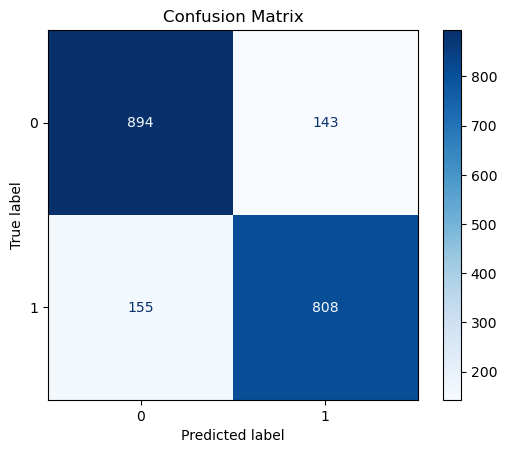

In [29]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [33]:
print(type(X))
print(X.shape)

print(type(y))
print(y.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(10000, 5000)
<class 'pandas.core.series.Series'>
(10000,)


In [35]:
X = df["review"]
y = df["label"]

In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.8495 0.831  0.8225 0.832  0.8435]
Average Accuracy: 0.8356999999999999


Conclusion

• The review text was preprocessed using lowercasing and stopword removal.
• TF-IDF was used for feature extraction.
• Logistic Regression was used for sentiment classification.
• The model achieved good accuracy on the test data.
• Cross-validation confirmed that the model performs consistently.
• This model can automatically classify Amazon reviews into Positive and Negative sentiments.